# 5. Unified environmental focus dataset

This notebook first explains how the final CSV is built, then it analyzes the result so we can decide whether it is sensible for comfort prediction.


## What was done

The merge script combines seven CSV files into one row-level environmental dataset:

- `data/interim/keti_1min_resampled.csv`
- `data/raw/room_conditions.csv`
- `data/processed/1_room_measurements_with_comfort.csv`
- `data/raw/HomeCoach_5min_2023.csv`
- `data/raw/HomeCoach_5min_2024.csv`
- `data/raw/HomeCoach_5min_2025.csv`
- `data/raw/HomeCoach_5min_2026.csv`

The output is `data/processed/unified_environment_focus_dataset.csv`, plus `data/processed/unified_environment_focus_dataset_report.csv` for source-level quality checks.

The correct merge is a vertical union after standardizing column names. These files do not describe the same physical room at the same timestamp, so a timestamp join would create fake sensor rows.


In [1]:
# Imports
from pathlib import Path
import sys

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ModuleNotFoundError:
    display = print

try:
    import matplotlib.pyplot as plt
    from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs matplotlib. From the MAL folder, run: "
        "python -m pip install -r requirements.txt"
    ) from exc

plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [2]:
# Find the MAL folder whether this notebook is run from the repo root or from notebooks/data_related.
def find_mal_dir(start: Path) -> Path:
    for path in [start, *start.parents]:
        if path.name == "MAL" and (path / "data").exists():
            return path

        candidate = path / "MAL"
        if candidate.exists() and (candidate / "data").exists():
            return candidate

    raise RuntimeError("Could not find the MAL directory")


MAL_DIR = find_mal_dir(Path.cwd().resolve())
sys.path.insert(0, str(MAL_DIR))

DATA_PATH = MAL_DIR / "data" / "processed" / "unified_environment_focus_dataset.csv"
REPORT_PATH = MAL_DIR / "data" / "processed" / "unified_environment_focus_dataset_report.csv"

MAL_DIR, DATA_PATH.exists(), REPORT_PATH.exists()


(WindowsPath('C:/Users/alsal/Documents/GitHub/SEP4/MAL'), True, True)

## Input files and builder settings


In [3]:
from scripts.build_unified_environment_dataset import (
    DEFAULT_OUTPUT_PATH,
    DEFAULT_REPORT_PATH,
    DEFAULT_SOURCES,
    OUTPUT_COLUMNS,
    build_unified_dataset,
)

source_files = pd.DataFrame(
    {
        "source": source.name,
        "path": source.path.relative_to(MAL_DIR),
        "exists": source.path.exists(),
    }
    for source in DEFAULT_SOURCES
)

display(source_files)
print("Output columns:")
print(OUTPUT_COLUMNS)


,source,path,exists
0,keti_1min_resampled,data\interim\keti_1min_resampled.csv,True
1,room_conditions,data\raw\room_conditions.csv,True
2,room_measurements_with_comfort,data\processed\1_room_measurements_with_comfor...,True
3,homecoach_5min_2023,data\raw\HomeCoach_5min_2023.csv,True
4,homecoach_5min_2024,data\raw\HomeCoach_5min_2024.csv,True
5,homecoach_5min_2025,data\raw\HomeCoach_5min_2025.csv,True
6,homecoach_5min_2026,data\raw\HomeCoach_5min_2026.csv,True


Output columns:
['timestamp', 'session_id', 'location_id', 'record_id', 'source', 'humidity', 'light', 'temperature', 'noise', 'co2', 'focus_score']


## Build or load the final CSV

Set `REBUILD_DATASET = True` if you want to rerun the combine step from scratch. By default the notebook loads the existing generated CSV and only builds it if it is missing.


In [4]:
REBUILD_DATASET = False

if REBUILD_DATASET or not DATA_PATH.exists() or not REPORT_PATH.exists():
    final_df, report_df = build_unified_dataset()
else:
    final_df = pd.read_csv(DATA_PATH, parse_dates=["timestamp"], low_memory=False)
    report_df = pd.read_csv(REPORT_PATH, parse_dates=["first_timestamp", "last_timestamp"])

df = final_df
report = report_df

print(f"Dataset path: {DATA_PATH}")
print(f"Report path: {REPORT_PATH}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")
print(f"Rows with focus_score: {df['focus_score'].notna().sum():,}")


Dataset path: C:\Users\alsal\Documents\GitHub\SEP4\MAL\data\processed\unified_environment_focus_dataset.csv
Report path: C:\Users\alsal\Documents\GitHub\SEP4\MAL\data\processed\unified_environment_focus_dataset_report.csv
Rows: 866,348
Columns: 11
Rows with focus_score: 1,830


## Column preview

Before deeper analysis, check the actual columns and a few rows. This is the quickest way to spot a wrong name, unexpected unit, or missing target.


In [5]:
print("Columns:")
print(df.columns.tolist())

display(df.head(10))


Columns:
['timestamp', 'session_id', 'location_id', 'record_id', 'source', 'humidity', 'light', 'temperature', 'noise', 'co2', 'focus_score']


,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23 16:06:00+00:00,keti_1min_resampled__510__s00001,510,keti_1min_resampled:row_00192329,keti_1min_resampled,NaN,NaN,NaN,NaN,316.00,NaN
1,2013-08-23 16:24:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011995,keti_1min_resampled,NaN,NaN,NaN,NaN,476.56,NaN
2,2013-08-23 16:25:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011996,keti_1min_resampled,NaN,NaN,NaN,NaN,480.33,NaN
3,2013-08-23 16:26:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011997,keti_1min_resampled,NaN,NaN,NaN,NaN,485.17,NaN
4,2013-08-23 16:27:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011998,keti_1min_resampled,NaN,NaN,NaN,NaN,481.08,NaN
5,2013-08-23 16:28:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00011999,keti_1min_resampled,NaN,NaN,NaN,NaN,482.25,NaN
6,2013-08-23 16:29:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00012000,keti_1min_resampled,NaN,NaN,NaN,NaN,483.33,NaN
7,2013-08-23 16:30:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00012001,keti_1min_resampled,NaN,NaN,NaN,NaN,480.00,NaN
8,2013-08-23 16:31:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00012002,keti_1min_resampled,NaN,NaN,NaN,NaN,475.83,NaN
9,2013-08-23 16:32:00+00:00,keti_1min_resampled__415__s00001,415,keti_1min_resampled:row_00012003,keti_1min_resampled,NaN,NaN,NaN,NaN,488.83,NaN


In [6]:
# Compact preview of the columns used for the first comfort-modeling experiments.
model_columns = ["humidity", "light", "temperature", "noise", "co2", "focus_score"]
sensor_columns = ["humidity", "light", "temperature", "noise", "co2"]

display(df[["timestamp", "source", "location_id", "session_id", *model_columns]].head(10))


,timestamp,source,location_id,session_id,humidity,light,temperature,noise,co2,focus_score
0,2013-08-23 16:06:00+00:00,keti_1min_resampled,510,keti_1min_resampled__510__s00001,NaN,NaN,NaN,NaN,316.00,NaN
1,2013-08-23 16:24:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,476.56,NaN
2,2013-08-23 16:25:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,480.33,NaN
3,2013-08-23 16:26:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,485.17,NaN
4,2013-08-23 16:27:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,481.08,NaN
5,2013-08-23 16:28:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,482.25,NaN
6,2013-08-23 16:29:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,483.33,NaN
7,2013-08-23 16:30:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,480.00,NaN
8,2013-08-23 16:31:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,475.83,NaN
9,2013-08-23 16:32:00+00:00,keti_1min_resampled,415,keti_1min_resampled__415__s00001,NaN,NaN,NaN,NaN,488.83,NaN


## Final schema

The builder keeps the model-relevant sensor columns and adds traceability columns so rows can be grouped and audited later.


In [7]:
schema_notes = pd.DataFrame([
    {"column": "timestamp", "meaning": "Measurement time, parsed and written consistently", "model_feature_now": False},
    {"column": "session_id", "meaning": "Time-bounded block inside a location", "model_feature_now": False},
    {"column": "location_id", "meaning": "Stable room, zone, student, device, or fallback grouping", "model_feature_now": False},
    {"column": "record_id", "meaning": "Stable row identifier with source prefix", "model_feature_now": False},
    {"column": "source", "meaning": "Dataset the row came from", "model_feature_now": False},
    {"column": "humidity", "meaning": "Relative humidity when available", "model_feature_now": True},
    {"column": "light", "meaning": "Light level when available", "model_feature_now": True},
    {"column": "temperature", "meaning": "Temperature when available", "model_feature_now": True},
    {"column": "noise", "meaning": "Noise level when available", "model_feature_now": True},
    {"column": "co2", "meaning": "CO2 level when available", "model_feature_now": True},
    {"column": "focus_score", "meaning": "Target label, mapped from comfort/rating columns", "model_feature_now": "target"},
])

display(schema_notes)


,column,meaning,model_feature_now
0,timestamp,"Measurement time, parsed and written consistently",False
1,session_id,Time-bounded block inside a location,False
2,location_id,"Stable room, zone, student, device, or fallbac...",False
3,record_id,Stable row identifier with source prefix,False
4,source,Dataset the row came from,False
5,humidity,Relative humidity when available,True
6,light,Light level when available,True
7,temperature,Temperature when available,True
8,noise,Noise level when available,True
9,co2,CO2 level when available,True


## ID relationship diagram

Raw location-like columns are normalized into `location_id`. Then `session_id` is created from existing session values when present, otherwise from location plus timestamp gaps.


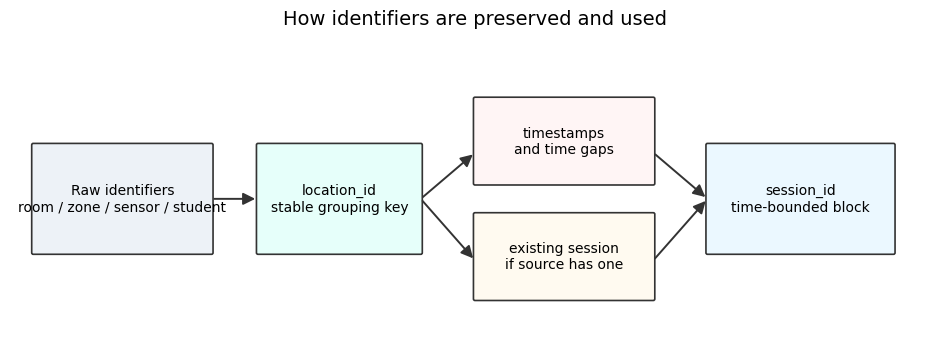

In [8]:
def draw_box(ax, xy, width, height, text, color):
    box = FancyBboxPatch(
        xy,
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.2,
        edgecolor="#333333",
        facecolor=color,
    )
    ax.add_patch(box)
    ax.text(
        xy[0] + width / 2,
        xy[1] + height / 2,
        text,
        ha="center",
        va="center",
        fontsize=10,
        wrap=True,
    )


def draw_arrow(ax, start, end):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.4,
        color="#333333",
    )
    ax.add_patch(arrow)


fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4)
ax.axis("off")

draw_box(ax, (0.3, 1.25), 2.3, 1.4, "Raw identifiers\nroom / zone / sensor / student", "#edf2f7")
draw_box(ax, (3.2, 1.25), 2.1, 1.4, "location_id\nstable grouping key", "#e6fffa")
draw_box(ax, (6.0, 2.15), 2.3, 1.1, "timestamps\nand time gaps", "#fff5f5")
draw_box(ax, (6.0, 0.65), 2.3, 1.1, "existing session\nif source has one", "#fffaf0")
draw_box(ax, (9.0, 1.25), 2.4, 1.4, "session_id\ntime-bounded block", "#ebf8ff")

draw_arrow(ax, (2.6, 1.95), (3.2, 1.95))
draw_arrow(ax, (5.3, 1.95), (6.0, 2.55))
draw_arrow(ax, (5.3, 1.95), (6.0, 1.15))
draw_arrow(ax, (8.3, 2.55), (9.0, 1.95))
draw_arrow(ax, (8.3, 1.15), (9.0, 1.95))

ax.set_title("How identifiers are preserved and used", fontsize=14, pad=12)
plt.show()


# Analysis


## Source provenance and coverage


In [9]:
coverage_columns = [
    "source",
    "raw_rows",
    "output_rows",
    "dropped_empty_rows",
    "labeled_rows",
    "unique_locations",
    "unique_sessions",
    "first_timestamp",
    "last_timestamp",
]

display(report[coverage_columns].sort_values("output_rows", ascending=False))


,source,raw_rows,output_rows,dropped_empty_rows,labeled_rows,unique_locations,unique_sessions,first_timestamp,last_timestamp
0,keti_1min_resampled,604891,550161,54730,0,51,473,2013-08-23 16:06:00+00:00,2013-09-01 06:58:00+00:00
4,homecoach_5min_2024,100325,100325,0,0,1,368,2024-01-01 00:02:30+00:00,2024-12-31 23:54:31+00:00
5,homecoach_5min_2025,100190,100190,0,0,1,365,2025-01-01 00:02:30+00:00,2025-12-31 23:59:31+00:00
3,homecoach_5min_2023,77045,77045,0,0,1,287,2023-03-04 09:12:50+00:00,2023-12-31 23:59:31+00:00
6,homecoach_5min_2026,34132,34132,0,0,1,130,2026-01-01 00:02:30+00:00,2026-05-06 15:47:49+00:00
1,room_conditions,2665,2665,0,0,1,3,2015-02-02 14:19:00+00:00,2015-02-04 10:43:00+00:00
2,room_measurements_with_comfort,1830,1830,0,1830,4,71,2025-09-17 13:37:11+00:00,2025-12-19 14:01:19+00:00


In [10]:
source_summary = df.groupby("source").agg(
    rows=("record_id", "count"),
    labeled_rows=("focus_score", lambda values: int(values.notna().sum())),
    locations=("location_id", "nunique"),
    sessions=("session_id", "nunique"),
).sort_values("rows", ascending=False)

display(source_summary)


,rows,labeled_rows,locations,sessions
source,,,,
keti_1min_resampled,550161,0,51,473
homecoach_5min_2024,100325,0,1,368
homecoach_5min_2025,100190,0,1,365
homecoach_5min_2023,77045,0,1,287
homecoach_5min_2026,34132,0,1,130
room_conditions,2665,0,1,3
room_measurements_with_comfort,1830,1830,4,71


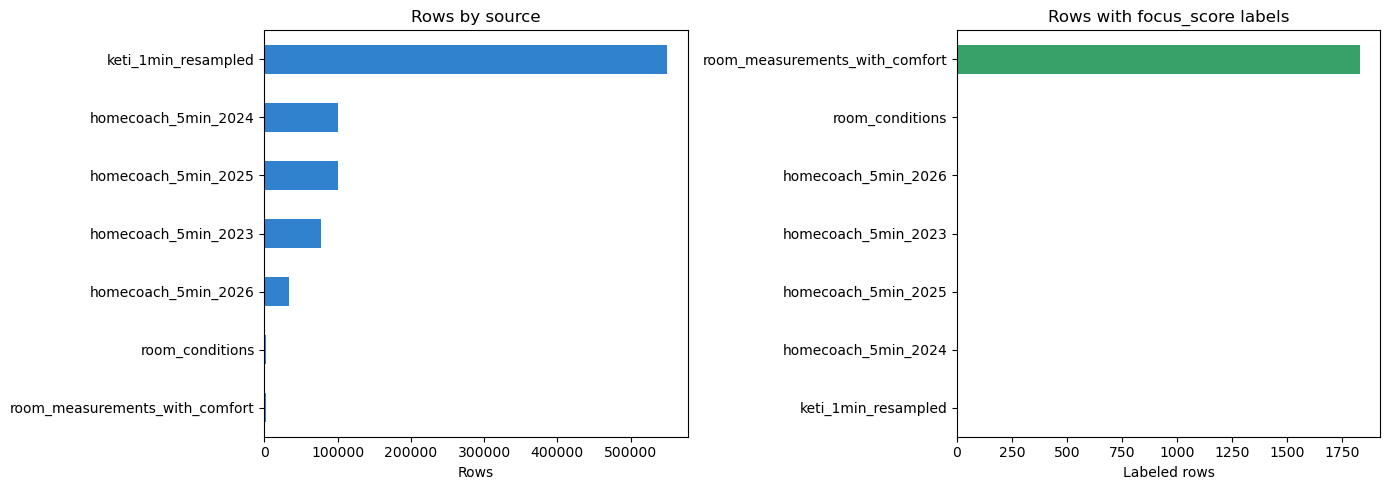

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_summary["rows"].sort_values().plot(kind="barh", ax=axes[0], color="#3182ce")
axes[0].set_title("Rows by source")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("")

source_summary["labeled_rows"].sort_values().plot(kind="barh", ax=axes[1], color="#38a169")
axes[1].set_title("Rows with focus_score labels")
axes[1].set_xlabel("Labeled rows")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


## Quick structural overview

This creates one small DataFrame per source, similar to the earlier mock-data notebooks.


In [12]:
datasets = {
    f"Data {index}: {source}": source_df
    for index, (source, source_df) in enumerate(df.groupby("source", sort=True), start=1)
}

overview = pd.DataFrame({
    name: {
        "Rows": data_x.shape[0],
        "Columns": data_x.shape[1],
        "Missing values": int(data_x.isna().sum().sum()),
        "Locations": data_x["location_id"].nunique(),
        "Sessions": data_x["session_id"].nunique(),
        "Labeled rows": int(data_x["focus_score"].notna().sum()),
    }
    for name, data_x in datasets.items()
}).T

display(overview.sort_values("Rows", ascending=False))


,Rows,Columns,Missing values,Locations,Sessions,Labeled rows
Data 5: keti_1min_resampled,550161,11,1128971,51,473,0
Data 2: homecoach_5min_2024,100325,11,200650,1,368,0
Data 3: homecoach_5min_2025,100190,11,200380,1,365,0
Data 1: homecoach_5min_2023,77045,11,154090,1,287,0
Data 4: homecoach_5min_2026,34132,11,68264,1,130,0
Data 6: room_conditions,2665,11,5330,1,3,0
Data 7: room_measurements_with_comfort,1830,11,1830,4,71,1830


## Simple range checks

These plain `describe()` checks help catch unit mismatches, broken imports, or values far outside the other sources.


In [13]:
for name, data_x in datasets.items():
    print(f"{name} Ranges:")
    display(data_x[model_columns].describe().T)


Data 1: homecoach_5min_2023 Ranges:


,count,mean,std,min,25%,50%,75%,max
humidity,"77,045.00",50.88,5.77,29.00,47.00,51.00,55.00,69.00
light,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,"77,045.00",23.14,3.21,15.70,20.20,22.80,26.10,31.50
noise,"77,045.00",40.12,10.67,31.00,32.00,35.00,45.00,83.00
co2,"77,045.00",905.63,466.24,338.00,521.00,730.00,"1,221.00","5,000.00"
focus_score,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data 2: homecoach_5min_2024 Ranges:


,count,mean,std,min,25%,50%,75%,max
humidity,"100,325.00",50.90,6.73,27.00,47.00,51.00,55.00,72.00
light,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,"100,325.00",22.03,3.55,15.60,19.30,21.00,24.10,31.60
noise,"100,325.00",40.50,9.15,31.00,32.00,38.00,46.00,80.00
co2,"100,325.00",841.48,401.69,333.00,524.00,708.00,"1,067.00","4,270.00"
focus_score,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data 3: homecoach_5min_2025 Ranges:


...

,count,mean,std,min,25%,50%,75%,max
humidity,"548,600.00",56.75,4.30,42.12,53.98,57.01,59.73,71.88
light,"548,600.00",82.28,309.00,0.00,3.50,4.33,30.17,"2,393.67"
temperature,"548,602.00",23.16,1.07,20.18,22.53,23.11,23.70,27.55
noise,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
co2,"526,193.00",421.63,91.09,250.00,361.17,414.75,464.92,"1,669.50"
focus_score,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data 6: room_conditions Ranges:


,count,mean,std,min,25%,50%,75%,max
humidity,"2,665.00",25.35,2.44,22.10,23.26,25.00,26.86,31.47
light,"2,665.00",193.23,250.21,0.00,0.00,0.00,442.50,"1,697.25"
temperature,"2,665.00",21.43,1.03,20.20,20.65,20.89,22.36,24.41
noise,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
co2,"2,665.00",717.91,292.68,427.50,466.00,580.50,956.33,"1,402.25"
focus_score,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data 7: room_measurements_with_comfort Ranges:


,count,mean,std,min,25%,50%,75%,max
humidity,"1,830.00",48.88,6.28,34.00,44.00,47.00,53.00,68.00
light,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temperature,"1,830.00",23.01,1.70,17.60,21.80,22.60,24.10,28.30
noise,"1,830.00",60.76,5.93,33.00,57.00,61.00,66.00,74.00
co2,"1,830.00",728.85,140.62,376.00,634.00,735.00,821.00,"1,444.00"
focus_score,"1,830.00",3.40,0.88,1.00,3.00,3.00,4.00,5.00


In [14]:
numeric_summary = []

for dataset_name, data_x in datasets.items():
    numeric_df = data_x.select_dtypes(include=np.number)

    for column in numeric_df.columns:
        numeric_summary.append({
            "Dataset": dataset_name,
            "Feature": column,
            "Min": numeric_df[column].min(),
            "Median": numeric_df[column].median(),
            "Mean": numeric_df[column].mean(),
            "Max": numeric_df[column].max(),
            "Std": numeric_df[column].std(),
            "Missing": int(numeric_df[column].isna().sum()),
        })

numeric_summary = pd.DataFrame(numeric_summary)

display(
    numeric_summary.sort_values(
        by=["Feature", "Dataset"]
    )
)


,Dataset,Feature,Min,Median,Mean,Max,Std,Missing
4,Data 1: homecoach_5min_2023,co2,338.00,730.00,905.63,"5,000.00",466.24,0
10,Data 2: homecoach_5min_2024,co2,333.00,708.00,841.48,"4,270.00",401.69,0
16,Data 3: homecoach_5min_2025,co2,330.00,770.00,925.64,"2,757.00",452.13,0
22,Data 4: homecoach_5min_2026,co2,329.00,"1,212.00","1,230.78","3,329.00",530.86,0
28,Data 5: keti_1min_resampled,co2,250.00,414.75,421.63,"1,669.50",91.09,23968
34,Data 6: room_conditions,co2,427.50,580.50,717.91,"1,402.25",292.68,0
40,Data 7: room_measurements_with_comfort,co2,376.00,735.00,728.85,"1,444.00",140.62,0
5,Data 1: homecoach_5min_2023,focus_score,NaN,NaN,NaN,NaN,NaN,77045
11,Data 2: homecoach_5min_2024,focus_score,NaN,NaN,NaN,NaN,NaN,100325
17,Data 3: homecoach_5min_2025,focus_score,NaN,NaN,NaN,NaN,NaN,100190


## Visual anomaly detection

The plots compare numeric feature distributions by source. Values are clipped to the 1st and 99th percentile per source before plotting so a few extreme readings do not hide the main shape.


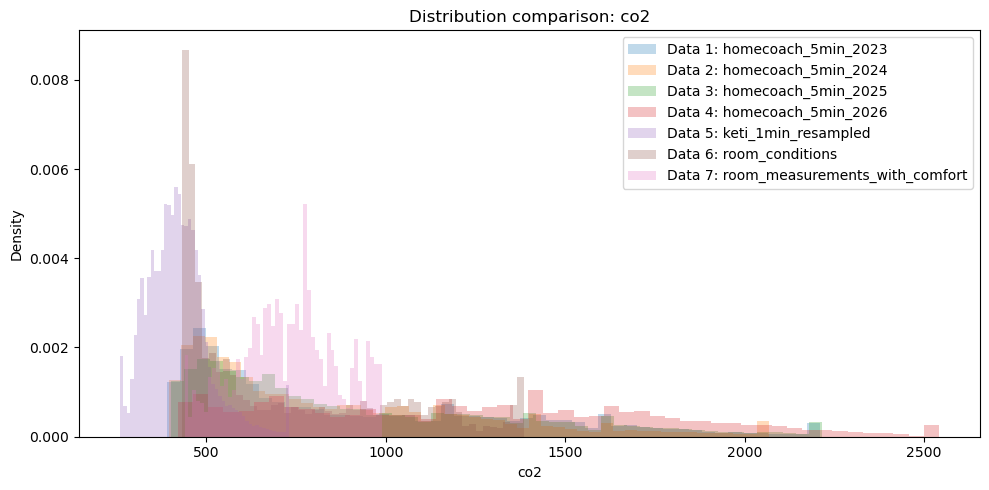

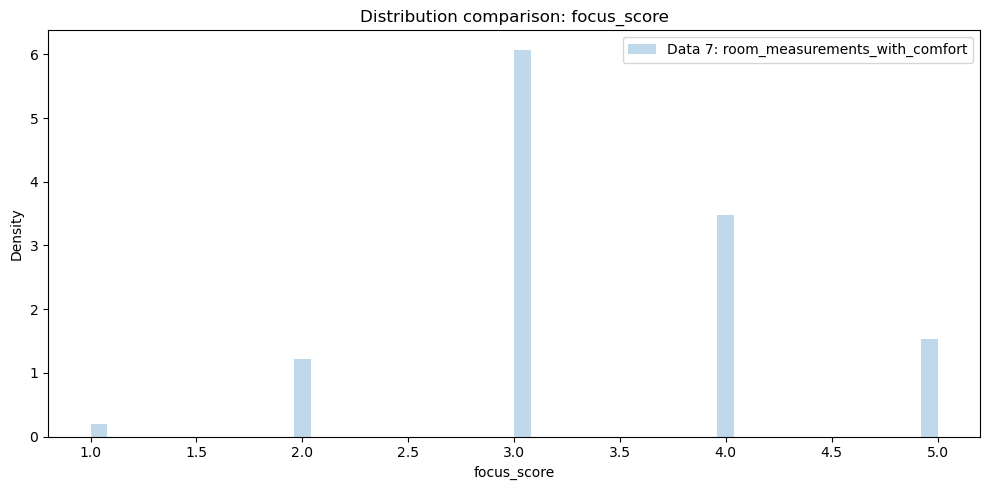

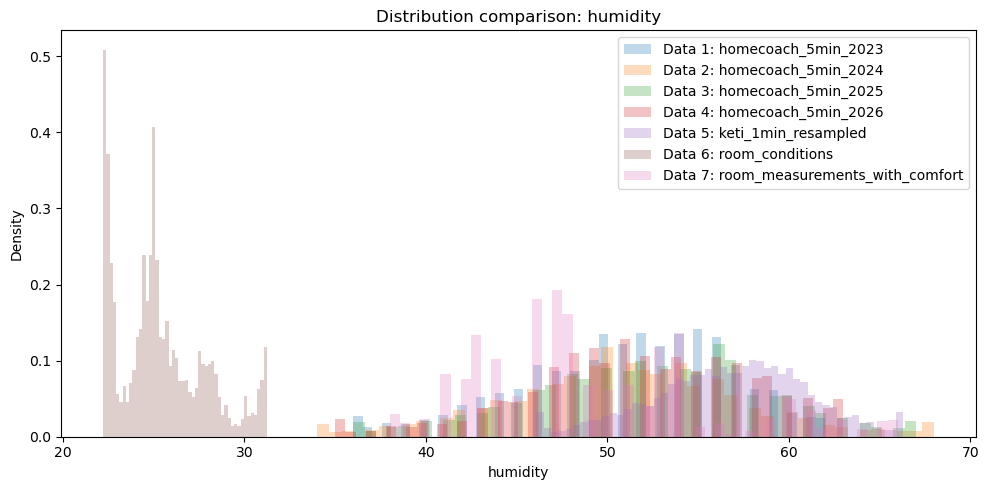

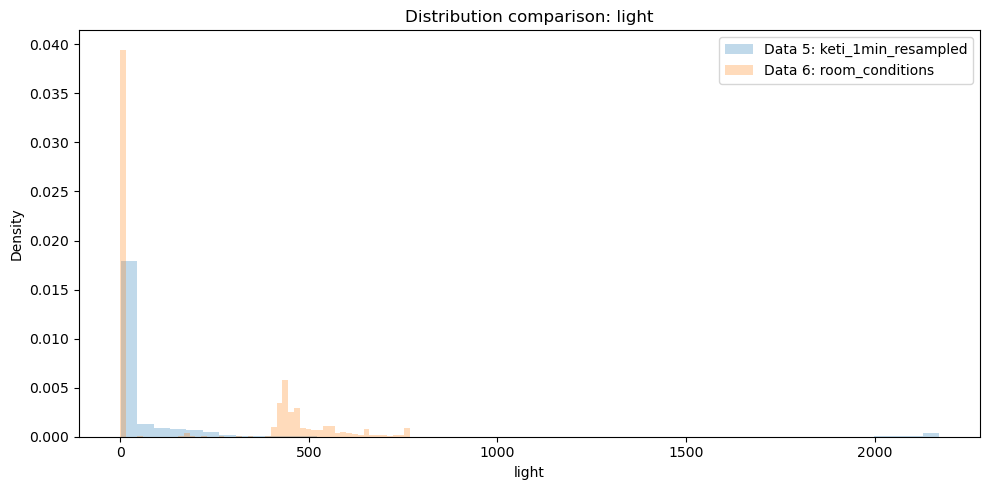

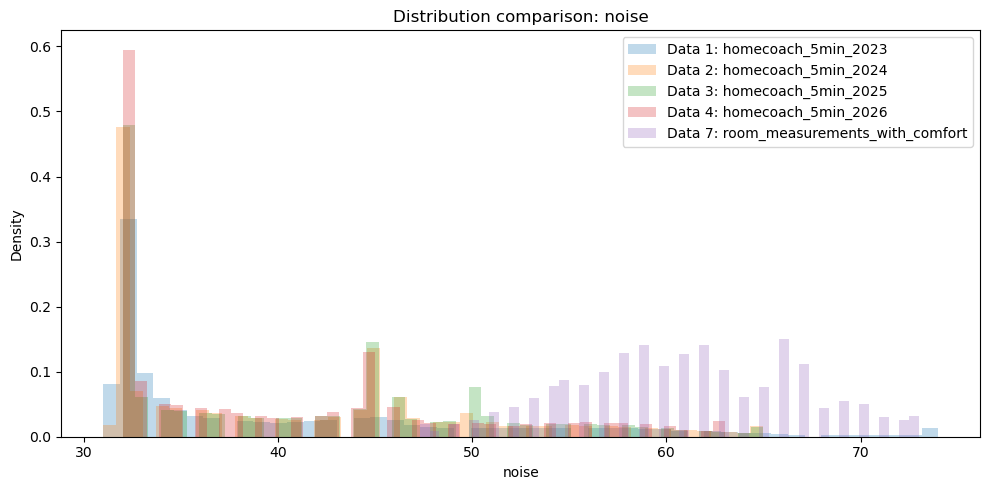

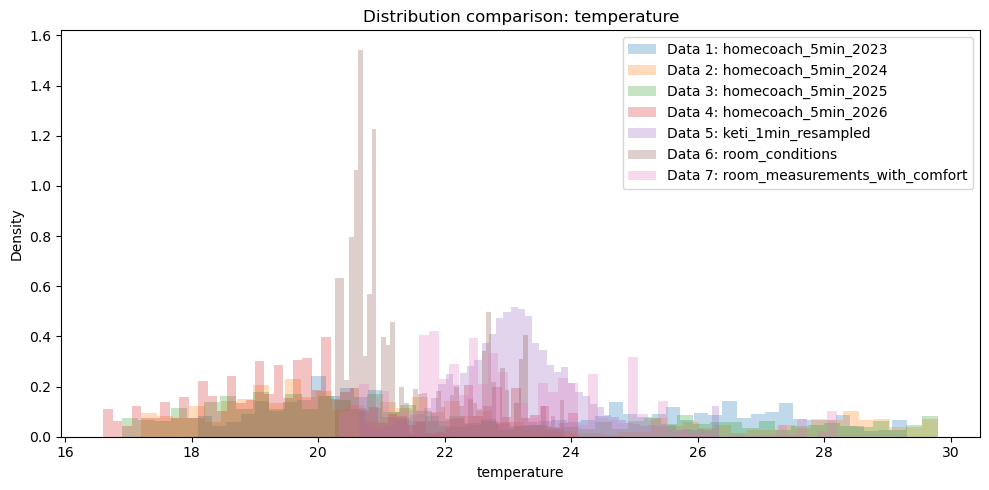

In [15]:
numeric_features = sorted(set(
    column
    for data_x in datasets.values()
    for column in data_x.select_dtypes(include=np.number).columns
))

for feature in numeric_features:
    fig, ax = plt.subplots(figsize=(10, 5))
    found = False

    for name, data_x in datasets.items():
        if feature not in data_x.columns:
            continue

        values = pd.to_numeric(data_x[feature], errors="coerce").dropna()
        if len(values) < 2:
            continue

        lower = values.quantile(0.01)
        upper = values.quantile(0.99)
        clipped = values.clip(lower, upper)
        ax.hist(clipped, bins=50, density=True, alpha=0.28, label=name)
        found = True

    if found:
        ax.set_title(f"Distribution comparison: {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        plt.close(fig)


## Missing value analysis

Missingness is expected because the public datasets do not all measure the same sensors. This is better than forcing fake values during the combine step.


In [16]:
missing_percent = df[model_columns].isna().mean().mul(100).sort_values(ascending=False)
display(missing_percent.to_frame("missing_percent"))


,missing_percent
focus_score,99.79
noise,63.81
light,36.37
co2,2.77
humidity,0.18
temperature,0.18


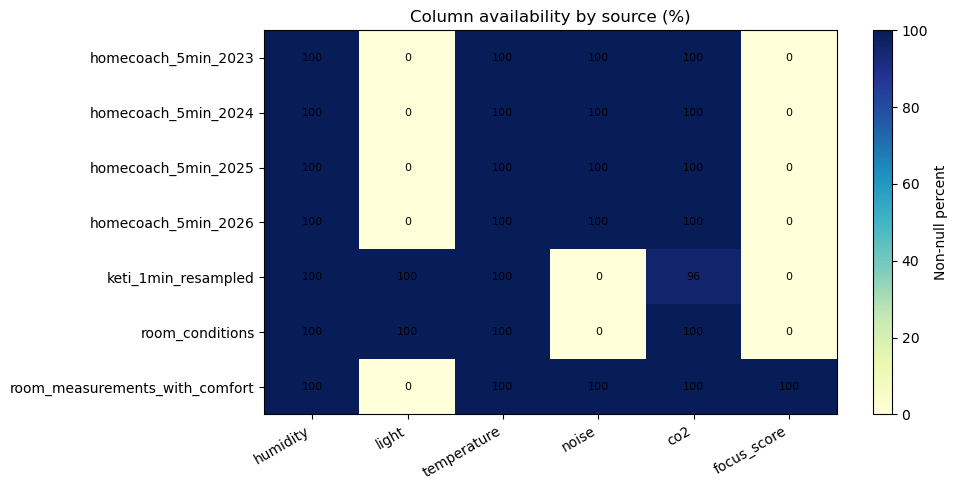

,humidity,light,temperature,noise,co2,focus_score
source,,,,,,
homecoach_5min_2023,100.00,0.00,100.00,100.00,100.00,0.00
homecoach_5min_2024,100.00,0.00,100.00,100.00,100.00,0.00
homecoach_5min_2025,100.00,0.00,100.00,100.00,100.00,0.00
homecoach_5min_2026,100.00,0.00,100.00,100.00,100.00,0.00
keti_1min_resampled,99.70,99.70,99.70,0.00,95.60,0.00
room_conditions,100.00,100.00,100.00,0.00,100.00,0.00
room_measurements_with_comfort,100.00,0.00,100.00,100.00,100.00,100.00


In [17]:
availability_by_source = df.groupby("source")[model_columns].apply(lambda part: part.notna().mean() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(availability_by_source.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(model_columns)))
ax.set_xticklabels(model_columns, rotation=30, ha="right")
ax.set_yticks(np.arange(len(availability_by_source.index)))
ax.set_yticklabels(availability_by_source.index)
ax.set_title("Column availability by source (%)")

for row in range(availability_by_source.shape[0]):
    for col in range(availability_by_source.shape[1]):
        value = availability_by_source.iloc[row, col]
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Non-null percent")
plt.tight_layout()
plt.show()

display(availability_by_source.round(1))


## Sensor ranges

These checks show scale differences and possible outliers before preprocessing.


In [18]:
range_summary = df.groupby("source")[sensor_columns].agg(["count", "min", "median", "mean", "max"])
display(range_summary)


humidity                            light       \
                                  count   min median  mean   max   count  min   
source                                                                          
homecoach_5min_2023               77045 29.00  51.00 50.88 69.00       0  NaN   
homecoach_5min_2024              100325 27.00  51.00 50.90 72.00       0  NaN   
homecoach_5min_2025              100190 31.00  53.00 52.29 72.00       0  NaN   
homecoach_5min_2026               34132 24.00  52.00 51.84 68.00       0  NaN   
keti_1min_resampled              548600 42.12  57.01 56.75 71.88  548600 0.00   
room_conditions                    2665 22.10  25.00 25.35 31.47    2665 0.00   
room_measurements_with_comfort     1830 34.00  47.00 48.88 68.00       0  NaN   

                                                      temperature        \
                               median   mean      max       count   min   
source                                                                    
homecoach_5min_2023               NaN    NaN      NaN       77045 15.70   
homecoach_5min_2024               NaN    NaN      NaN      100325 15.60   
homecoach_5min_2025               NaN    NaN      NaN      100190 16.00   
homecoach_5min_2026               NaN    NaN      NaN       34132 15.80   
keti_1min_resampled              4.33  82.28 2,393.67      548602 20.18   
room_conditions                  0.00 193.23 1,697.25        2665 20.20   
room_measurements_with_comfort    NaN    NaN      NaN        1830 17.60   

                                                    noise                     \
                               median  mean   max   count   min median  mean   
source                                                                         
homecoach_5min_2023             22.80 23.14 31.50   77045 31.00  35.00 40.12   
homecoach_5min_2024             21.00 22.03 31.60  100325 31.00  38.00 40.50   
homecoach_5min_2025             21.00 22.08 31.00  100190 31.00  40.00 41.18   
homecoach_5min_2026             19.90 20.10 25.20   34132 31.00  36.00 39.87   
keti_1min_resampled             23.11 23.16 27.55       0   NaN    NaN   NaN   
room_conditions                 20.89 21.43 24.41       0   NaN    NaN   NaN   
room_measurements_with_comfort  22.60 23.01 28.30    1830 33.00  61.00 60.76   

                                         co2                                    
                                 max   count    min   median     mean      max  
source                                                                          
homecoach_5min_2023            83.00   77045 338.00   730.00   905.63 5,000.00  
homecoach_5min_2024            80.00  100325 333.00   708.00   841.48 4,270.00  
homecoach_5min_2025            81.00  100190 330.00   770.00   925.64 2,757.00  
homecoach_5min_2026            81.00   34132 329.00 1,212.00 1,230.78 3,329.00  
keti_1min_resampled              NaN  526193 250.00   414.75   421.63 1,669.50  
room_conditions                  NaN    2665 427.50   580.50   717.91 1,402.25  
room_measurements_with_comfort 74.00    1830 376.00   735.00   728.85 1,444.00

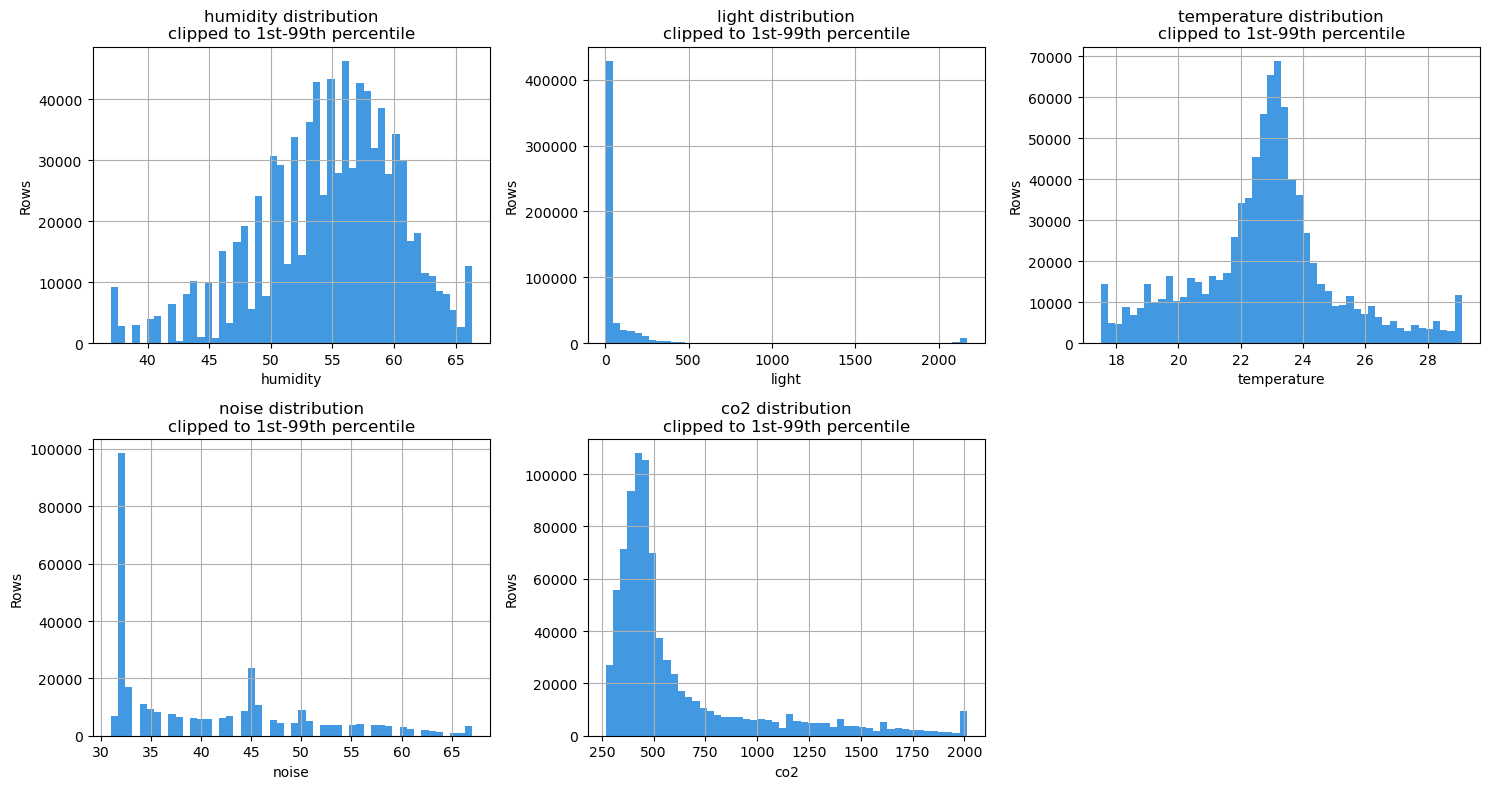

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, column in zip(axes, sensor_columns):
    values = df[column].dropna()
    if values.empty:
        ax.set_visible(False)
        continue

    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    values.clip(lower, upper).hist(bins=50, ax=ax, color="#4299e1")
    ax.set_title(f"{column} distribution\nclipped to 1st-99th percentile")
    ax.set_xlabel(column)
    ax.set_ylabel("Rows")

axes[-1].axis("off")
plt.tight_layout()
plt.show()


## Outliers (IQR Method)

This follows the same idea as `dataset_imputed_analysis.ipynb`: compute Q1, Q3, IQR, and count values outside `Q1 - 1.5 * IQR` and `Q3 + 1.5 * IQR`. These are candidates for review, not automatic deletion.


,column,non_null_rows,lower_bound,upper_bound,outlier_count,outlier_pct
1,light,551265,-36.88,70.79,102633,18.62
4,co2,842380,28.38,"1,004.04",113866,13.52
2,temperature,864789,18.55,26.95,79808,9.23
0,humidity,864787,39.86,70.30,16016,1.85
5,focus_score,1830,1.50,5.50,28,1.53
3,noise,313522,11.00,67.00,2925,0.93


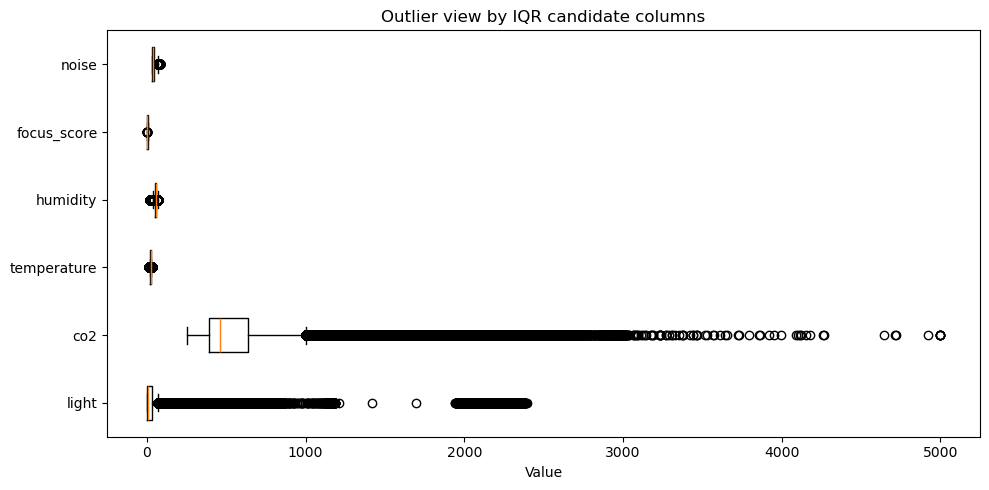

In [20]:
numeric_df = df[model_columns].apply(pd.to_numeric, errors="coerce")

if numeric_df.empty:
    print("No numeric columns found for outlier analysis.")
else:
    outlier_stats = []
    for column in numeric_df.columns:
        series = numeric_df[column].dropna()
        if series.empty:
            outlier_stats.append({
                "column": column,
                "non_null_rows": 0,
                "lower_bound": np.nan,
                "upper_bound": np.nan,
                "outlier_count": 0,
                "outlier_pct": 0.0,
            })
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 if iqr == 0 else q1 - 1.5 * iqr
        upper = q3 if iqr == 0 else q3 + 1.5 * iqr
        outliers = ((series < lower) | (series > upper)).sum()
        outlier_pct = (outliers / len(series)) * 100 if len(series) else 0

        outlier_stats.append({
            "column": column,
            "non_null_rows": len(series),
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": int(outliers),
            "outlier_pct": float(outlier_pct),
        })

    outlier_df = pd.DataFrame(outlier_stats).sort_values(by="outlier_pct", ascending=False)
    display(outlier_df)

    top_cols = outlier_df[outlier_df["outlier_count"] > 0].head(6)["column"].tolist()
    if not top_cols:
        print("No outliers detected by IQR rule.")
    else:
        plot_data = [numeric_df[column].dropna() for column in top_cols]
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.boxplot(plot_data, vert=False, labels=top_cols, showfliers=True)
        ax.set_title("Outlier view by IQR candidate columns")
        ax.set_xlabel("Value")
        plt.tight_layout()
        plt.show()


In [21]:
outlier_by_source = []

for source, source_df in df.groupby("source"):
    source_numeric = source_df[model_columns].apply(pd.to_numeric, errors="coerce")
    for column in source_numeric.columns:
        series = source_numeric[column].dropna()
        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 if iqr == 0 else q1 - 1.5 * iqr
        upper = q3 if iqr == 0 else q3 + 1.5 * iqr
        outliers = ((series < lower) | (series > upper)).sum()

        outlier_by_source.append({
            "source": source,
            "column": column,
            "non_null_rows": len(series),
            "outlier_count": int(outliers),
            "outlier_pct": (outliers / len(series)) * 100,
            "lower_bound": lower,
            "upper_bound": upper,
        })

outlier_by_source_df = pd.DataFrame(outlier_by_source)
display(outlier_by_source_df.sort_values("outlier_pct", ascending=False).head(20))


,source,column,non_null_rows,outlier_count,outlier_pct,lower_bound,upper_bound
17,keti_1min_resampled,light,548600,101944,18.58,-36.50,70.17
18,keti_1min_resampled,temperature,548602,28092,5.12,20.76,25.47
2,homecoach_5min_2023,noise,77045,2809,3.65,12.50,64.50
25,room_measurements_with_comfort,temperature,1830,58,3.17,18.35,27.55
19,keti_1min_resampled,co2,526193,15033,2.86,205.54,620.54
4,homecoach_5min_2024,humidity,100325,2480,2.47,35.00,67.00
7,homecoach_5min_2024,co2,100325,2235,2.23,-290.50,"1,881.50"
28,room_measurements_with_comfort,focus_score,1830,28,1.53,1.50,5.50
12,homecoach_5min_2026,humidity,34132,452,1.32,36.00,68.00
11,homecoach_5min_2025,co2,100190,1158,1.16,-412.00,"2,188.00"


## Focus score labels

The current true supervised labels come from `1_room_measurements_with_comfort.csv`. Other sources are still useful for sensor distribution analysis and future imputation, but they are not labeled training examples yet.


In [22]:
labeled_df = df[df["focus_score"].notna()].copy()
labeled_df["focus_score"] = labeled_df["focus_score"].astype(int)

print(f"Labeled rows: {len(labeled_df):,}")
display(labeled_df.groupby(["source", "focus_score"]).size().unstack(fill_value=0))
display(labeled_df.head(10))


Labeled rows: 1,830


focus_score,1,2,3,4,5
source,,,,,
room_measurements_with_comfort,28,179,889,509,225


,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
801476,2025-09-17 13:37:11+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000624,room_measurements_with_comfort,65.00,NaN,25.10,61.00,522.00,4
801477,2025-09-17 13:37:50+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000625,room_measurements_with_comfort,65.00,NaN,25.10,61.00,522.00,5
801480,2025-09-17 13:44:41+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000626,room_measurements_with_comfort,64.00,NaN,25.20,61.00,506.00,3
801481,2025-09-17 13:46:32+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000627,room_measurements_with_comfort,64.00,NaN,25.20,61.00,506.00,4
801487,2025-09-17 14:09:50+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000628,room_measurements_with_comfort,63.00,NaN,25.30,60.00,516.00,4
801489,2025-09-17 14:22:48+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000629,room_measurements_with_comfort,63.00,NaN,25.40,61.00,490.00,5
801495,2025-09-17 14:44:27+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000630,room_measurements_with_comfort,63.00,NaN,25.40,59.00,496.00,5
801499,2025-09-17 15:00:23+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000631,room_measurements_with_comfort,62.00,NaN,25.50,60.00,507.00,3
801501,2025-09-17 15:06:10+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000632,room_measurements_with_comfort,62.00,NaN,25.50,58.00,487.00,4
801502,2025-09-17 15:08:33+00:00,room_measurements_with_comfort__lab_4_2__s00001,lab_4_2,room_measurements_with_comfort:row_00000633,room_measurements_with_comfort,62.00,NaN,25.50,58.00,487.00,5


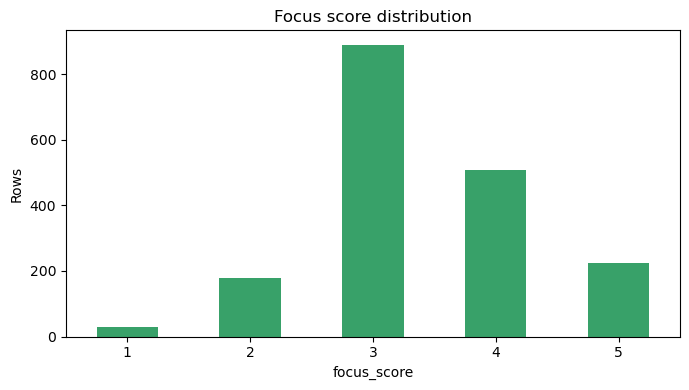

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
labeled_df["focus_score"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#38a169")
ax.set_title("Focus score distribution")
ax.set_xlabel("focus_score")
ax.set_ylabel("Rows")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()


## Correlation matrix for labeled rows

This is only a first diagnostic. The labeled dataset is small compared with the full sensor history, and correlations do not prove causation.


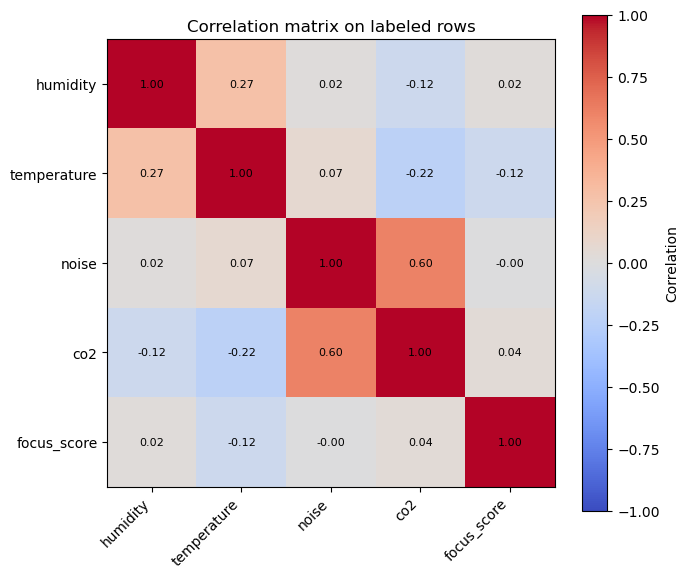

,humidity,temperature,noise,co2,focus_score
humidity,1.00,0.27,0.02,-0.12,0.02
temperature,0.27,1.00,0.07,-0.22,-0.12
noise,0.02,0.07,1.00,0.60,-0.00
co2,-0.12,-0.22,0.60,1.00,0.04
focus_score,0.02,-0.12,-0.00,0.04,1.00


In [24]:
corr_data = labeled_df[model_columns].dropna(axis=1, how="all")
corr = corr_data.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Correlation matrix on labeled rows")

for row in range(corr.shape[0]):
    for col in range(corr.shape[1]):
        value = corr.iloc[row, col]
        if pd.notna(value):
            ax.text(col, row, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()

display(corr)


### Interpreting the correlation values

Correlations like `humidity`/`temperature = 0.27` and `noise`/`co2 = 0.60` can be reasonable. The unified table is a vertical union of different rooms, years, sensors, and sampling rates, so global correlations include both physical relationships and source effects. A moderate `noise`/`co2` correlation is especially plausible because both can rise when occupancy increases. Use these numbers as diagnostics, not proof that one variable causes another.


In [25]:
pairs_to_check = [("humidity", "temperature"), ("noise", "co2")]
pair_rows = []

for source, source_df in df.groupby("source"):
    for left, right in pairs_to_check:
        pair_data = source_df[[left, right]].dropna()
        pair_rows.append({
            "source": source,
            "pair": f"{left} / {right}",
            "rows_used": len(pair_data),
            "correlation": pair_data[left].corr(pair_data[right]) if len(pair_data) >= 2 else np.nan,
        })

pair_correlation_by_source = pd.DataFrame(pair_rows)
display(pair_correlation_by_source.sort_values(["pair", "source"]))


,source,pair,rows_used,correlation
0,homecoach_5min_2023,humidity / temperature,77045,-0.00
2,homecoach_5min_2024,humidity / temperature,100325,0.14
4,homecoach_5min_2025,humidity / temperature,100190,-0.11
6,homecoach_5min_2026,humidity / temperature,34132,-0.57
8,keti_1min_resampled,humidity / temperature,548595,-0.68
10,room_conditions,humidity / temperature,2665,0.72
12,room_measurements_with_comfort,humidity / temperature,1830,0.27
1,homecoach_5min_2023,noise / co2,77045,-0.01
3,homecoach_5min_2024,noise / co2,100325,0.02
5,homecoach_5min_2025,noise / co2,100190,0.02


## Session and location analysis

This is where `location_id` and `session_id` both matter. If a location has many sessions, we can split by session or location to reduce leakage when evaluating models.


In [26]:
session_summary = df.groupby("session_id").agg(
    source=("source", "first"),
    location_id=("location_id", "first"),
    rows=("record_id", "count"),
    first_timestamp=("timestamp", "min"),
    last_timestamp=("timestamp", "max"),
    labeled_rows=("focus_score", lambda values: int(values.notna().sum())),
)
session_summary["duration_minutes"] = (
    session_summary["last_timestamp"] - session_summary["first_timestamp"]
).dt.total_seconds() / 60

location_summary = df.groupby("location_id").agg(
    sources=("source", "nunique"),
    sessions=("session_id", "nunique"),
    rows=("record_id", "count"),
    first_timestamp=("timestamp", "min"),
    last_timestamp=("timestamp", "max"),
)

display(session_summary.sort_values("rows", ascending=False).head(10))


,source,location_id,rows,first_timestamp,last_timestamp,labeled_rows,duration_minutes
session_id,,,,,,,
keti_1min_resampled__722__s00003,keti_1min_resampled,722,1440,2013-08-25 00:00:00+00:00,2013-08-25 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__510__s00006,keti_1min_resampled,510,1440,2013-08-28 00:00:00+00:00,2013-08-28 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__462__s00002,keti_1min_resampled,462,1440,2013-08-24 00:00:00+00:00,2013-08-24 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__462__s00003,keti_1min_resampled,462,1440,2013-08-25 00:00:00+00:00,2013-08-25 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__462__s00004,keti_1min_resampled,462,1440,2013-08-26 00:00:00+00:00,2013-08-26 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__462__s00007,keti_1min_resampled,462,1440,2013-08-29 00:00:00+00:00,2013-08-29 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__462__s00008,keti_1min_resampled,462,1440,2013-08-30 00:00:00+00:00,2013-08-30 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__734__s00003,keti_1min_resampled,734,1440,2013-08-25 00:00:00+00:00,2013-08-25 23:59:00+00:00,0,"1,439.00"
keti_1min_resampled__510__s00002,keti_1min_resampled,510,1440,2013-08-24 00:00:00+00:00,2013-08-24 23:59:00+00:00,0,"1,439.00"


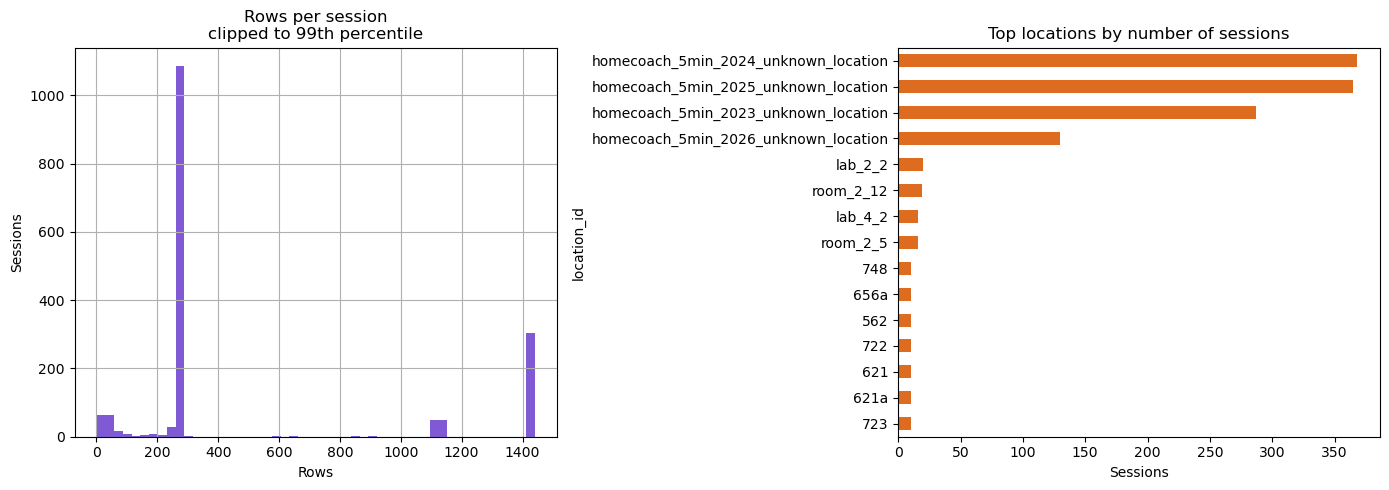

,sources,sessions,rows,first_timestamp,last_timestamp
location_id,,,,,
homecoach_5min_2024_unknown_location,1,368,100325,2024-01-01 00:02:30+00:00,2024-12-31 23:54:31+00:00
homecoach_5min_2025_unknown_location,1,365,100190,2025-01-01 00:02:30+00:00,2025-12-31 23:59:31+00:00
homecoach_5min_2023_unknown_location,1,287,77045,2023-03-04 09:12:50+00:00,2023-12-31 23:59:31+00:00
homecoach_5min_2026_unknown_location,1,130,34132,2026-01-01 00:02:30+00:00,2026-05-06 15:47:49+00:00
lab_2_2,1,20,623,2025-09-26 06:42:11+00:00,2025-12-12 12:08:42+00:00
room_2_12,1,19,672,2025-09-23 12:58:45+00:00,2025-12-09 16:01:35+00:00
room_2_5,1,16,249,2025-09-19 13:02:05+00:00,2025-12-19 14:01:19+00:00
lab_4_2,1,16,286,2025-09-17 13:37:11+00:00,2025-12-17 16:16:11+00:00
723,1,10,10932,2013-08-23 23:04:00+00:00,2013-09-01 06:30:00+00:00


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

session_summary["rows"].clip(upper=session_summary["rows"].quantile(0.99)).hist(
    bins=50,
    ax=axes[0],
    color="#805ad5",
)
axes[0].set_title("Rows per session\nclipped to 99th percentile")
axes[0].set_xlabel("Rows")
axes[0].set_ylabel("Sessions")

location_summary["sessions"].sort_values(ascending=False).head(15).sort_values().plot(
    kind="barh",
    ax=axes[1],
    color="#dd6b20",
)
axes[1].set_title("Top locations by number of sessions")
axes[1].set_xlabel("Sessions")
axes[1].set_ylabel("location_id")

plt.tight_layout()
plt.show()

display(location_summary.sort_values("sessions", ascending=False).head(10))


## Example time series

A quick look at one source/location helps confirm that timestamps and sessions are ordered correctly.


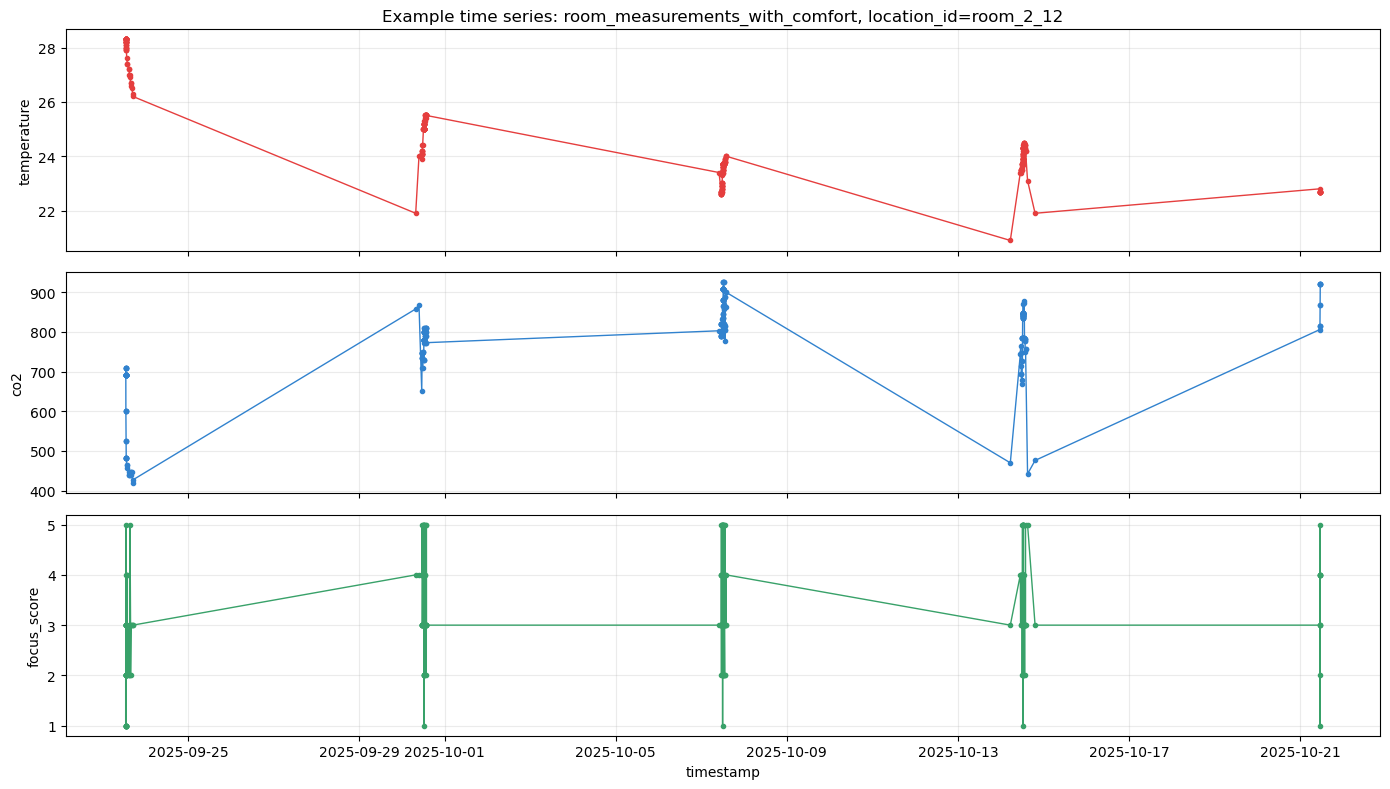

,timestamp,session_id,location_id,record_id,source,humidity,light,temperature,noise,co2,focus_score
803164,2025-09-23 12:58:45+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000910,room_measurements_with_comfort,54.00,NaN,28.20,71.00,708.00,1.00
803166,2025-09-23 12:59:55+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000911,room_measurements_with_comfort,54.00,NaN,28.20,71.00,708.00,1.00
803167,2025-09-23 13:00:13+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000912,room_measurements_with_comfort,54.00,NaN,28.20,71.00,708.00,2.00
803168,2025-09-23 13:00:15+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000913,room_measurements_with_comfort,54.00,NaN,28.20,71.00,708.00,1.00
803169,2025-09-23 13:00:36+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000914,room_measurements_with_comfort,54.00,NaN,28.20,71.00,708.00,2.00
803170,2025-09-23 13:00:40+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000915,room_measurements_with_comfort,54.00,NaN,28.30,65.00,691.00,3.00
803171,2025-09-23 13:00:41+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000916,room_measurements_with_comfort,54.00,NaN,28.30,65.00,691.00,3.00
803172,2025-09-23 13:00:49+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000917,room_measurements_with_comfort,54.00,NaN,28.30,65.00,691.00,2.00
803173,2025-09-23 13:00:56+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000918,room_measurements_with_comfort,54.00,NaN,28.30,65.00,691.00,2.00
803174,2025-09-23 13:01:09+00:00,room_measurements_with_comfort__room_2_12__s00001,room_2_12,room_measurements_with_comfort:row_00000919,room_measurements_with_comfort,54.00,NaN,28.30,65.00,691.00,2.00


In [28]:
example_source = "room_measurements_with_comfort" if "room_measurements_with_comfort" in set(df["source"]) else df["source"].iloc[0]
example_location = df.loc[df["source"].eq(example_source), "location_id"].mode().iloc[0]
example = df[df["source"].eq(example_source) & df["location_id"].eq(example_location)].sort_values("timestamp").head(300)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, column, color in zip(axes, ["temperature", "co2", "focus_score"], ["#e53e3e", "#3182ce", "#38a169"]):
    if column in example and example[column].notna().any():
        ax.plot(example["timestamp"], example[column], marker="o", markersize=3, linewidth=1, color=color)
    ax.set_ylabel(column)
    ax.grid(True, alpha=0.25)

axes[0].set_title(f"Example time series: {example_source}, location_id={example_location}")
axes[-1].set_xlabel("timestamp")
plt.tight_layout()
plt.show()

display(example.head(10))


## ML conclusions

1. Keep `session_id` and `location_id` out of the first sensor-only model features to avoid memorizing rooms or sessions.
2. Use `session_id` or `location_id` for train/test splitting so repeated measurements from the same room block do not leak across splits.
3. Handle missing `light` and `noise` in a preprocessing pipeline. Do not fill them during dataset combining.
4. Treat IQR outliers as candidates for review. Do not delete them blindly, because high CO2 or noise may be real and important for comfort prediction.
5. The unlabeled rows can still help with sensor range checks, drift monitoring, imputation experiments, and future pseudo-labeling.
